# Tree Drawing basics
Tree visualization is a fundamental feature of `toytree`. Following our minimalist ethos, it is possible to generate a beautiful tree drawing easily, while also being able to create complex and data rich visualizations by using many available styling options.

In [1]:
import numpy as np

import toytree

# an example tree
tree = toytree.rtree.bdtree(ntips=6, seed=123)

## Drawing class objects
When you call `.draw()` on a tree it returns three objects, a `Canvas`, a `Cartesian` axes, and a `Mark`. 

This follows the design principle of the `toyplot` plotting library on which toytree is based. The `Canvas` describes the plot space, and the `Cartesian` defines the coordinate space in data units, and `Marks` contain SVG markers/shapes to represent data. One canvas can have multiple cartesian axes, and each cartesian can contain multiple marks.

It is often useful to capture the returned (``Canvas``, ``Cartesian``, ``Mark``) objects as stored variables which allows you to optionally edit them further or save them to a file. If you are working in a jupyter notebook drawings are autorendered as HTML in output cells. This behavior can be toggled in the toyplot [Global config](#global-config).

Throughout this documentation you will see many `toytree` drawing commands end with a semicolon (;), which is a simple method to hide the returned objects from being displayed in the output cell.

In [2]:
# store the returned drawing objects
canvas, axes, mark = tree.draw()

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="300.0px" height="275.0px" viewBox="0 0 300.0 275.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t6daf436b5f1c4430b768c81de1ed103d"> r0 r1 r2 r3 r4 r5

## Saving drawings
You can [save/export drawings](drawing-save) in a number of formats to use in professional publications or for further editing in tools like Inkscape or Illustrator. The SVG format output is best for this, while the PDF and PNG are convenient for sharing. The HTML output retains interactive features such as hover tooltip info. To save a drawing pass the canvas and filename to `toytree.save`, the file type is inferred from the suffix.

In [3]:
toytree.save(canvas, "/tmp/drawing.svg")
toytree.save(canvas, "/tmp/drawing.html")
toytree.save(canvas, "/tmp/drawing.pdf")

## Tree Styles
A good way to think about ``draw()`` is that ``tree_style`` chooses a starting look, and the other arguments adjust specific parts of that look. The shorter alias ``ts`` is convenient when you are experimenting in a notebook. Built-in styles include ``n``, ``s``, ``p``, ``o``, ``c``, ``d``, ``b``, ``u`` and ``r``. See [Tree Styles](drawing-tree-styles). 

In [4]:
# drawing with pre-built 'c' (coalescent) style
tree.draw(tree_style="c")

# drawing with 'c' style and additional modifications applied on top
tree.draw(
    tree_style="c", node_markers="s", node_sizes=10, node_colors="salmon", height=250
);

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="300.0px" height="300.0px" viewBox="0 0 300.0 300.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t824e144d4fbb46ce944a4acac0835897"> 0 0.4 0.8 1.2 r0 r1 r2 r3 r4 r5

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="300.0px" height="250.0px" viewBox="0 0 300.0 250.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="td7670129d8834ea898d6c8d6c59f5ab1"> 0 0.4 0.8 1.2 r0 r1 r2 r3 r4 r5

## Drawing nodes and edges

Plotting node values is a useful way of representing data stored to a tree (see [Data/Features](core-feature-data)). The ``draw()`` command includes many options to apply styles to nodes or edges. These should be considered *convenience* options, as they provide only a subset of the styling options that can be accomplished using the [annotation](anno-introduction)`. 

Nodes are often used to show labels, support values, or trait data. They can convey information through variation in their marker shapes (e.g., circles, rectangles, pie-charts), colors, and sizes. Node markers in `toytree` are represented by SVG shape objects for which a fill (color), fill-opacity, stroke (outline color), stroke-opacity, and stroke-width can be set. Node labels can be added on top of nodes as formatted strings, and hover tooltip info can be added to display in the HTML/notebook rendering.

In [9]:
# hover over nodes to see pop-up elements
tree.draw(
    node_sizes=18,
    node_style={"fill-opacity": 0.75, "stroke": "white", "stroke-width": 2.5},
    node_labels="idx",
    node_labels_style={"font-size": 14, "fill": "white"},
    node_colors=("idx", "BlueRed", 6, 9),
    node_markers="s",
    node_mask=False,
    node_hover=True,
);

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="300.0px" height="275.0px" viewBox="0 0 300.0 275.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t031be4aa946849a3b3be4a5bcb13ae94"> idx: 0
dist: 1.27212638397
support: nan
height: 0
name: r0 0 idx: 1
dist: 1.27212638397
support: nan
height: 0
name: r1 1 idx: 2
dist: 0.488252765456
support: nan
height: 0
name: r2 2 idx: 3
dist: 0.44959453852
support: nan
height: 0
name: r3 3 idx: 4
dist: 0.271721229346
support: nan
height: 0
name: r4 4 idx: 5
dist: 0.271721229346
support: nan
height: 0
name: r5 5 idx: 6
dist: 0.125897349747
support: nan
height: 1.27212638397
name: 6 idx: 7
dist: 0.177873309174
support: nan
height: 0.271721229346
name: 7 idx: 8
dist: 0.0386582269365
support: nan
height: 0.44959453852
name: 8 idx: 9
dist: 0.90977096826
support: nan
height: 0.488252765456
name: 9 idx: 10
dist: 0.596972495123
support: nan
height: 1.39802373372
name: 10 r0 r1 r2 r3 r4 r5

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="300.0px" height="275.0px" viewBox="0 0 300.0 275.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="teca6b352806c443282a91515c36283e7"> r0 r1 r2 r3 r4 r5

In [15]:
# mask=True masks all nodes
tree.draw(node_mask=True, node_sizes=12);

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="300.0px" height="275.0px" viewBox="0 0 300.0 275.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="teb935070ab914115b43de8dc905767fd"> r0 r1 r2 r3 r4 r5

In [16]:
# mask=[True, False, True, ...] shows Nodes with True
mask = tree.get_node_mask(show_tips=True, show_root=True, show_internal=False)
print(mask)
tree.draw(node_mask=mask, node_sizes=12);

[ True  True  True  True  True  True False False False False  True]


<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="300.0px" height="275.0px" viewBox="0 0 300.0 275.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t21bc8f3638e04c37acc64234528ec301"> r0 r1 r2 r3 r4 r5

In [17]:
# mask=[True, False, True, ...] shows Nodes with True
mask = tree.get_node_mask("~r[0-5]")
print(mask)
tree.draw(node_mask=mask, node_sizes=12);

[ True  True  True  True  True  True False False False False False]


<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="300.0px" height="275.0px" viewBox="0 0 300.0 275.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="tb6f90d6848964ce4b7f4d5ee2108a4a5"> r0 r1 r2 r3 r4 r5

In [279]:
# mask=[True, False, True, ...] shows a subset of Nodes
mask = tree.get_node_mask(2, 3, 7, 8)
print(mask)
tree.draw(node_mask=mask, node_sizes=15, node_labels="idx");

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="300.0px" height="275.0px" viewBox="0 0 300.0 275.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t201bf63172df43cd8c48a11482ea2174"> 2 3 7 8 r0 r1 r2 r3 r4 r5

### node_markers
Node markers are the shapes of the mark objects plotted on nodes. The default shape is a circle, but a variety of marker shapes are available and can be selected by the shorthand str names used for [toyplot markers](https://toyplot.readthedocs.io/en/stable/markers.html). For example, 's' for a square, 'o' for a circle, 'r1x5' for a rectangle that is 5 times taller than wide. Each marker shape is still scaled to a particular pixel size using the `node_sizes` argument, and optionally shown or hidden using `node_mask`. You can enter a single node marker argument to apply to all nodes uniformly, or a series of node markers of length nnodes to apply different markers shapes to different nodes.

In [24]:
# apply square markers to all nodes
tree.draw(node_sizes=10, node_markers="s");

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="300.0px" height="275.0px" viewBox="0 0 300.0 275.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="td10016f7de4f46b592a00175b620889b"> r0 r1 r2 r3 r4 r5

In [35]:
# apply rectangle markers to each node
tree.draw(node_sizes=15, node_markers="r2x1");

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="300.0px" height="275.0px" viewBox="0 0 300.0 275.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t45888802714d4a9da23eb2300046ef2b"> r0 r1 r2 r3 r4 r5

In [36]:
# apply a rectangle marker with width scaled to n digits in data
rects = [f"r{len(str(i))}x1" for i in tree.get_node_data("idx")]
tree.draw(node_sizes=15, node_markers=rects, node_labels="idx");

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="300.0px" height="275.0px" viewBox="0 0 300.0 275.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="ta4ac72b7bbda48ecb0fba04558155dab"> 6 7 8 9 10 r0 r1 r2 r3 r4 r5

In [58]:
# show
tree = tree.set_node_data("support", default=100)
tree[-1].support = np.nan
tree.draw(node_labels="support", node_sizes=18, node_markers="r2x1");

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="300.0px" height="275.0px" viewBox="0 0 300.0 275.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="tcf1b5d5874bb48a9b218788d3c8d9f09"> 100 100 100 100 nan r0 r1 r2 r3 r4 r5

In [224]:
# ...
mask = tree.get_node_mask(2, 9, 10)
canvas, axes, mark = tree.draw()
tree.annotate.add_node_markers(axes=axes, marker="s", size=10, mask=mask);

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="300.0px" height="275.0px" viewBox="0 0 300.0 275.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t3f061bf302d64ef087a0edf7fcb7226d"> r0 r1 r2 r3 r4 r5

### node_colors
The fill color of nodes can be set in a variety of ways. The node_colors option can be used to set a single color to all nodes, or different colors to nodes. The colors can be entered manually, or they can be automatically projected from color map to data values. There is another option for setting a single color to all nodes, using node_style.fill. The node_colors argument overrides node_style.fill.

In [72]:
# set a single color to all nodes
tree.draw(node_colors="red", node_sizes=10);

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="300.0px" height="275.0px" viewBox="0 0 300.0 275.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t0aa5294e87704f9ea9396e7afa9fc8c3"> r0 r1 r2 r3 r4 r5

In [73]:
# list of colors of length nnodes
colors = ["darkcyan"] * 6 + ["goldenrod"] * 5
tree.draw(node_colors=colors, node_sizes=10, node_mask=False);

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="300.0px" height="275.0px" viewBox="0 0 300.0 275.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t0d7181b1338f48f8a5602dbf287ec1fa"> r0 r1 r2 r3 r4 r5

Automatically color nodes by projecting a data feature that is saved to tree object, such as the node heights, using [color-mapping](/toytree/color-mapping).

In [76]:
# colormapping the 'height' feature
tree.draw(node_colors="height", node_sizes=10, node_mask=False);

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="300.0px" height="275.0px" viewBox="0 0 300.0 275.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="tae0404a31ecb4193bcbb03a74d42c395"> r0 r1 r2 r3 r4 r5

## Global config
The default visualization settings in toytree are inherited from toyplot. This includes the default usage of html format for displaying plots in a notebook, and the default behavior of automatically rendering Canvas objects in a notebook cell when they are created. Both of these options can be changed in the `config` settings of the toyplot library.

In [24]:
import toyplot

# set config options to new settings
toyplot.config.autoformat = "png"
toyplot.config.autorender = False

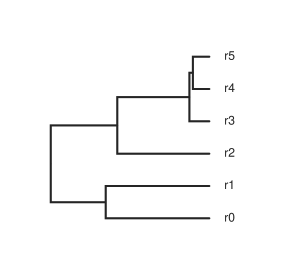

In [25]:
# embed a PNG drawing in the notebook
canvas, axes, mark = tree.draw()

# it will only display here b/c we return the Canvas
canvas

In [26]:
# set config options back to their defaults
toyplot.config.autoformat = "html"
toyplot.config.autorender = True